# <span style="color: rgb(230, 0, 126);"> Sprint 10 - Projecte. </span>

Nom alumne: Roser Blasco							

Ja hem muntat una base de dades de famílies de l'AFA amb dos taules, una de famílies i una altra de nens.

### Llibreries, connexió i dataframes

Llibreries

In [533]:
%pip install pymysql
import pymysql
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker


# Tamble plottable per a fer taules
%pip install plottable
from plottable import Table

%pip install plotly
import plotly.express as px
import plotly.graph_objects as go

%pip install nbformat


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Connexió

In [534]:
# Ens conectem a la base de dades
connexio = pymysql.connect(host='localhost',
                             user='root',
                             password= 'M@3QLr007',
                             db='sprint_10_roser_bbdd_afa')

if connexio.open:
        print("S'ha connectact amb èxit a la base de dades modelat_sql_roser4")


S'ha connectact amb èxit a la base de dades modelat_sql_roser4


Dataframes

In [535]:
# Creem un cursor per a executar consultes
cursor = connexio.cursor()

# Obtemin el llistat de les taules en la base de dades
cursor.execute("SHOW TABLES")
taules = cursor.fetchall()

# Creem un diccionari per a enmagatzemar els dataframes
sprint_10_roser_bbdd_afa_sql_a_python = {}
print("S'ha creat la base de dades buida sprint_10_roser_bbdd_afa_sql_a_python")

# Llegim cada taula com un DataFrame i l'enmagatzemem en el diccionari
for taula in taules:
    nom_taula = taula[0]  # Comemcen per la primera taula
    llegeix = f"SELECT * FROM {nom_taula}" # Funció que en SQL selecciona tot de cada taula 
    df = pd.read_sql(llegeix, connexio) # Llegeix cada taula com a dataFrame i 
    sprint_10_roser_bbdd_afa_sql_a_python[nom_taula] = df  # Enmagatzemar el DataFrame en el diccionari


# Imprimim la llista de dataframes enmagatzemats en el diccionari
print("S'han afegit les següents taules a la base de dades sprint_10_roser_bbdd_afa_sql_a_python")
for nom_taula, df in sprint_10_roser_bbdd_afa_sql_a_python.items():
    print(f"- {nom_taula}")

S'ha creat la base de dades buida sprint_10_roser_bbdd_afa_sql_a_python
S'han afegit les següents taules a la base de dades sprint_10_roser_bbdd_afa_sql_a_python
- acollida_anonimitzat
- acollida_restringit
- extraescolar_angles_2425
- extraescolar_basquet_2425
- extraescolar_cuinafreda_2425
- extraescolar_eso_2425
- extraescolar_gim_36_2425
- extraescolar_gim_i52_2425
- extraescolar_iesportiva_2425
- extraescolar_manualitats_2425
- extraescolar_multiesport_2425
- extraescolar_musica_2425
- extraescolar_patinatge_2425
- extraescolar_piscina_2425
- extraescolar_prefutbol_2425
- extraescolar_robotica_2425
- extraescolar_taekwondo_2425
- extraescolar_voleiprimaria_2425
- extraescolar_zumba_2425
- families_anonimitzat
- families_restringit
- infants_anonimitzat
- tots_els_infants


C:\Users\Roser\AppData\Local\Temp\ipykernel_10996\2647795033.py:16: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



### Tamany famílies escola

Volem saber com es distribueixen les famílies de diferents tamanys a l'escola. La limitació és que només tindrem dades dels infants que han compartit dades amb nosaltres a través de la TokApp.

In [536]:
# Creem un dataframe anonimitzat, unnt les dues taules anonimitzades i comprovem les columnes que tenim
taula_anonimitzada = sprint_10_roser_bbdd_afa_sql_a_python['families_anonimitzat'].merge(sprint_10_roser_bbdd_afa_sql_a_python['infants_anonimitzat'], left_on='id_familia', right_on='id_familia', how="outer", suffixes=('_families', '_infants'))
for columna in taula_anonimitzada.columns:
    print(columna)

id_familia
estatus_socis
id_infant


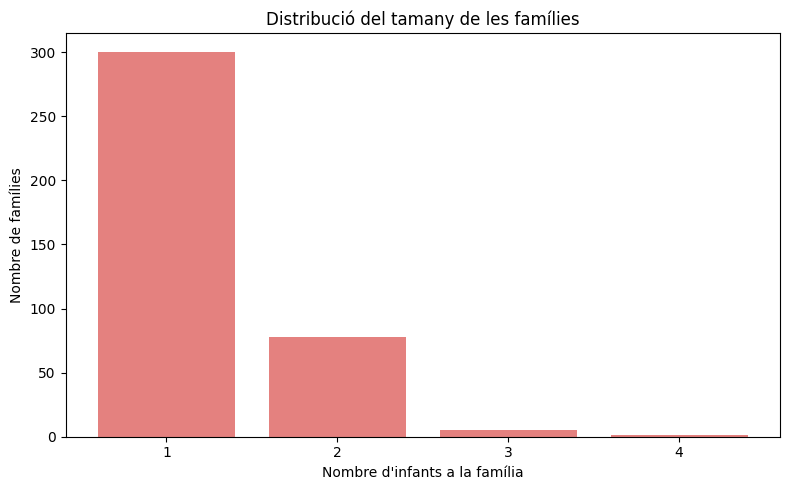

In [537]:
# Grafiquem el tamany de les famílies 
tamany_families = taula_anonimitzada.groupby('id_familia')['id_infant'].count()
distribucio_tamany_families = tamany_families.value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(distribucio_tamany_families.index, distribucio_tamany_families.values, color = ['#E4817Fff'])

plt.xlabel('Nombre d\'infants a la família')
plt.ylabel('Nombre de famílies')
plt.title('Distribució del tamany de les famílies')
plt.xticks(distribucio_tamany_families.index)
plt.tight_layout()
plt.show()

I ara, si les famílies de l'AFA són significativament diferents en tamany de les que no són de l'AFA. 

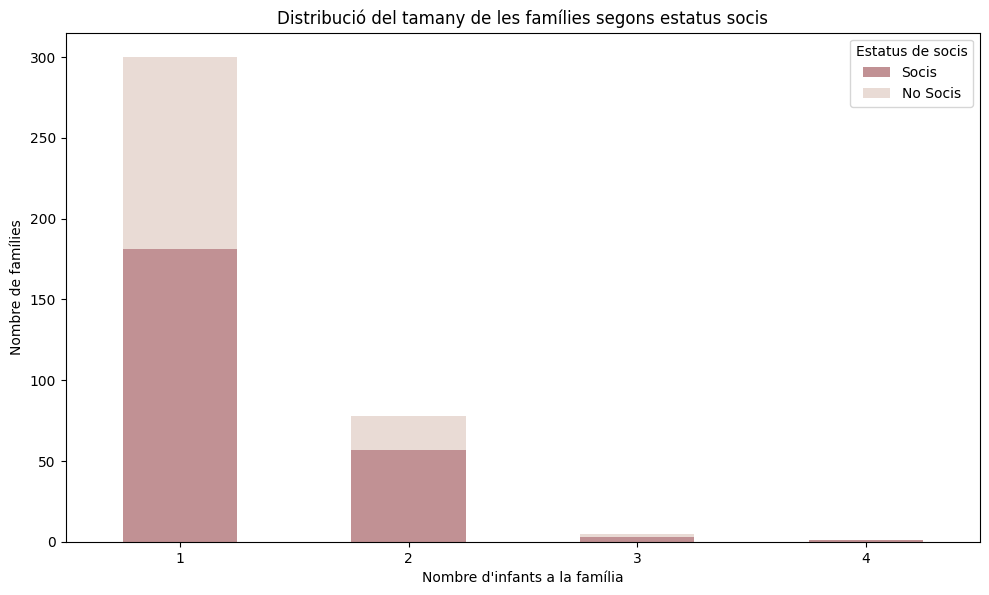

In [538]:
# Calculem el nombre d'infants per cada família i el seu estatus
tamany_families_amb_estatus = taula_anonimitzada.groupby(['id_familia', 'estatus_socis'])['id_infant'].count().reset_index()
tamany_families_amb_estatus.columns = ['id_familia', 'estatus_socis', 'num_children']

# Calculem el nombre total d'infants per cada família
total_infants_per_familia = tamany_families_amb_estatus.groupby('id_familia')['num_children'].sum().reset_index()
total_infants_per_familia.columns = ['id_familia', 'family_size']

# Afegim la columna 'family_size' al dataframe original
tamany_families_amb_estatus = pd.merge(tamany_families_amb_estatus, total_infants_per_familia, on='id_familia')

# Pivot per a tenir el recompte de socis i no-socis per tamany de família
taula_tamany_estatus = tamany_families_amb_estatus.pivot_table(
    index='family_size',
    columns='estatus_socis',
    values='id_familia',
    aggfunc='count',
    fill_value=0
)


# Grafiquem com gràfic de barres apilades
taula_tamany_estatus.sort_index(inplace=True) 
taula_tamany_estatus.columns = ['No Socis', 'Socis'] # Noms de les etiquetes
taula_tamany_estatus = taula_tamany_estatus[['Socis', 'No Socis']] # Reordenem per tenir els socis a sota


taula_tamany_estatus.plot(kind='bar', stacked=True, color=['#C19194ff', '#E9DBD5ff'], figsize=(10, 6))

plt.xlabel('Nombre d\'infants a la família')
plt.ylabel('Nombre de famílies')
plt.title('Distribució del tamany de les famílies segons estatus socis')
plt.legend(title='Estatus de socis')
plt.tight_layout()
plt.xticks(rotation=0)

plt.savefig("distribucio_tamany_families_2.png", dpi=300)
plt.show()


Ara convertirem a percentatges per a poder comparar millor

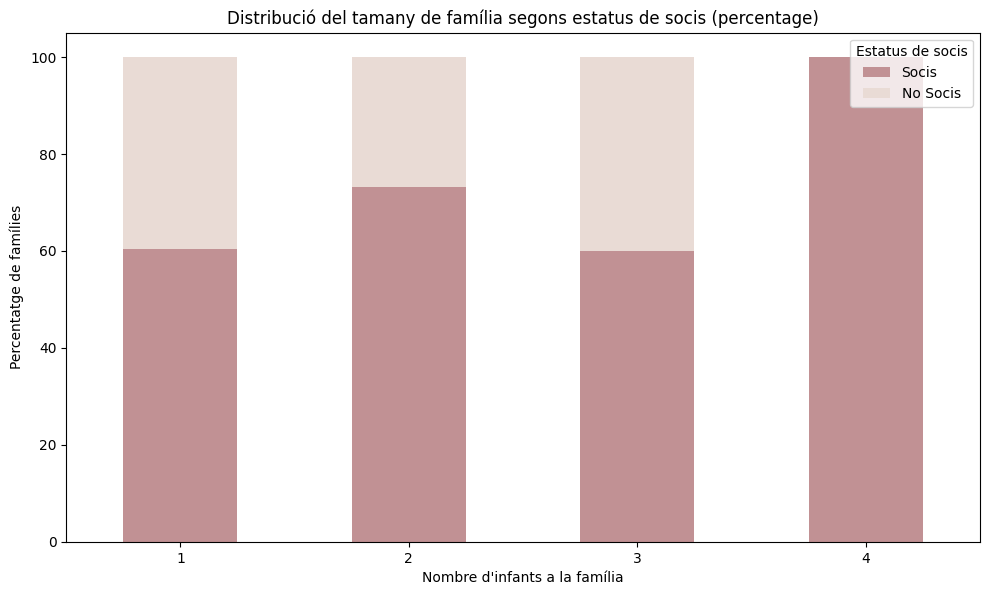

In [539]:
# Convertim en percentatges per a cada tamany de família 
taula_tamany_estatus_percentage = taula_tamany_estatus.div(taula_tamany_estatus.sum(axis=1), axis=0) * 100

taula_tamany_estatus_percentage.plot(
    kind='bar',
    stacked=True,
    color=['#C19194ff', '#E9DBD5ff'],  # Socios, Not Socios
    figsize=(10, 6)
)

plt.xlabel('Nombre d\'infants a la família')
plt.ylabel('Percentatge de famílies')
plt.title('Distribució del tamany de família segons estatus de socis (percentage)')
plt.legend(title='Estatus de socis', labels=['Socis', 'No Socis'])
plt.tight_layout()
plt.xticks(rotation=0)
plt.savefig("pivot_percentage.png", dpi=300)
plt.show()

Imprimirem la de tamany de família segons si són o no socis 

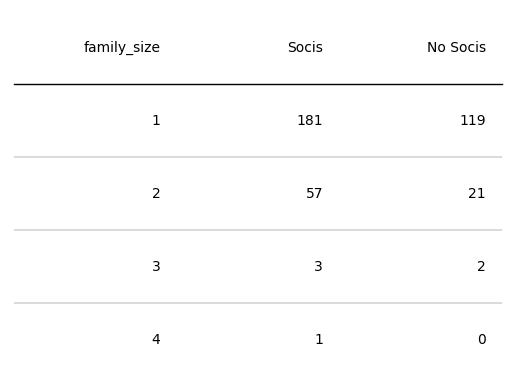

In [540]:
taula_tamany_families = Table(taula_tamany_estatus)
plt.savefig("taula_families.png", dpi=300)
plt.show()

### Ludoteca (acollida)

Ara volem saber com es distribueixen els infants amb acollida domiciliada entre els diferents cursos

Primer definirem un diccioanri per a normalitzar el nom dels cursos i poder-lo utilitzar més endavant.
Així, tindran el nom correcte en totes les gràfiques. 

In [541]:
# Diccionari per a normalitzar el nom dels cursos
cursos_estandar = {
    'I3': 'I3',
    'P3': 'I3',
    'I4': 'I4',
    'P4': 'I4',
    'I5': 'I5',
    'P5': 'I5',
    'i5': 'I5',
    'I5 B': 'I5',
    '1r': '1r',
    '1er B': '1r',
    '1r de primària': '1r',
    '1RO': '1r',
    '2n': '2n',
    '2NDO': '2n',
    '2n de primària': '2n',
    '3r': '3r',
    '3RO': '3r',
    '3er B': '3r',
    '3er A': '3r',
    '3r de primària': '3r',
    '4r': '4t',
    '4rt': '4t',
    '4TO': '4t',
    '4t': '4t',
    '4t de primària': '4t',
    '5è': '5è',
    '5é': '5è',
    '5TO': '5è',
    '6è': '6è',
    '6è A': '6è',
    '6è B': '6è',
    '6TO': '6è',
    '6è de primària': '6è',
    '1r ESO': 'ESO',
    "1r d'ESO": 'ESO',
    '2n ESO': 'ESO',
    '3r ESO': 'ESO',
    '4t ESO': 'ESO',
    'ESO': 'ESO',
    '': 'Desconegut'
}




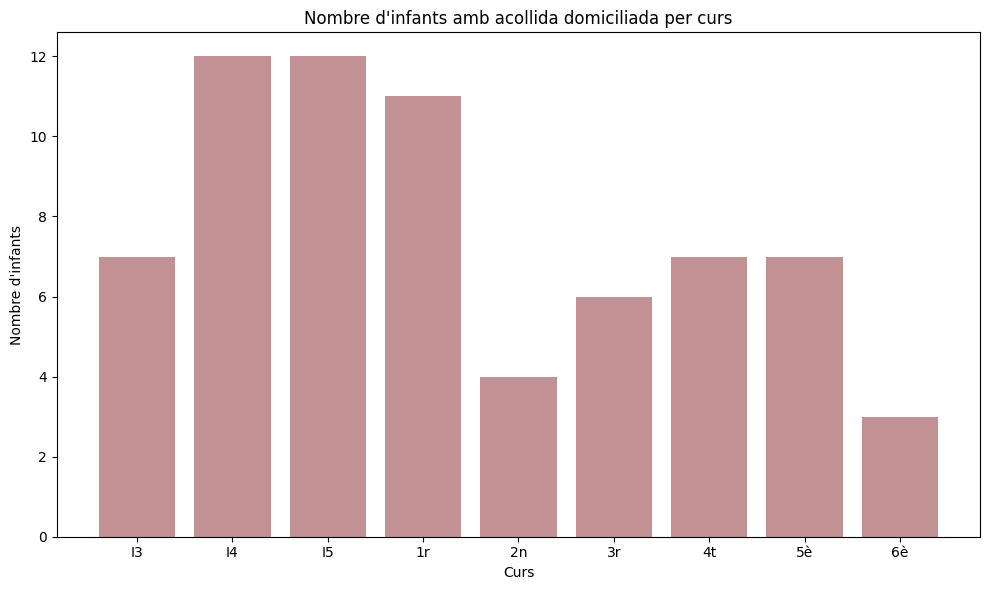

In [542]:
# Fem una taula que calculi el nombre d'infants per cada curs d'acollida, contant també els infants sense id_infant
acollida_cursos = sprint_10_roser_bbdd_afa_sql_a_python['acollida_restringit'].groupby(['curs']).size().reset_index(name='num_infants')
acollida_cursos.columns = ['curs', 'num_infants']

# Apliquem la estandarització a la columna curs
acollida_cursos['curs'] = acollida_cursos['curs'].map(cursos_estandar).fillna(acollida_cursos['curs'])

# Forcem l'ordre dels cursos d'infants més petits a més grans 
ordre_cursos = ['I3', 'I4', 'I5', '1r', '2n', '3r', '4t', '5è', '6è', '1r ESO', '2n ESO', '3r ESO', '4t ESO', 'ESO','Desconegut']

acollida_cursos['curs'] = pd.Categorical(acollida_cursos['curs'], categories=ordre_cursos, ordered=True) # Aqui ens assegurem que 'curs' està en l'ordre categòric correcte
 
acollida_cursos = acollida_cursos.sort_values('curs') # Roendem el dataframe per la columna 'curs' per a que estigui en l'ordre correcte

# Grafiquem
plt.figure(figsize=(10, 6))
plt.bar(acollida_cursos['curs'], acollida_cursos['num_infants'], color='#C19194ff')

# Etiquetes i títol
plt.xlabel('Curs')
plt.ylabel('Nombre d\'infants')
plt.title('Nombre d\'infants amb acollida domiciliada per curs')
plt.tight_layout()
plt.savefig("acollida_cursos_barres_2.png", dpi=300)
plt.show()


Ho visualitzem en una taula

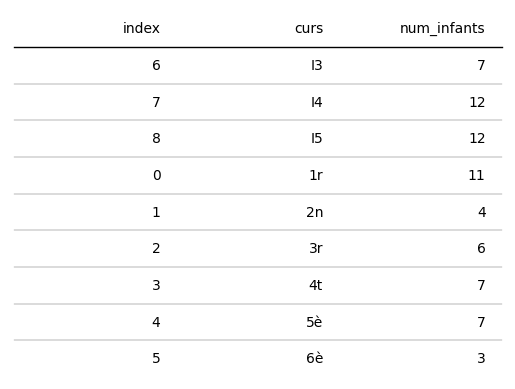

In [543]:
taula_acollida_cursos = Table(acollida_cursos)
plt.savefig("taula_acollida_cursos.png", dpi=300)
plt.show()

Seguim amb acollida i comparem matí i tarda


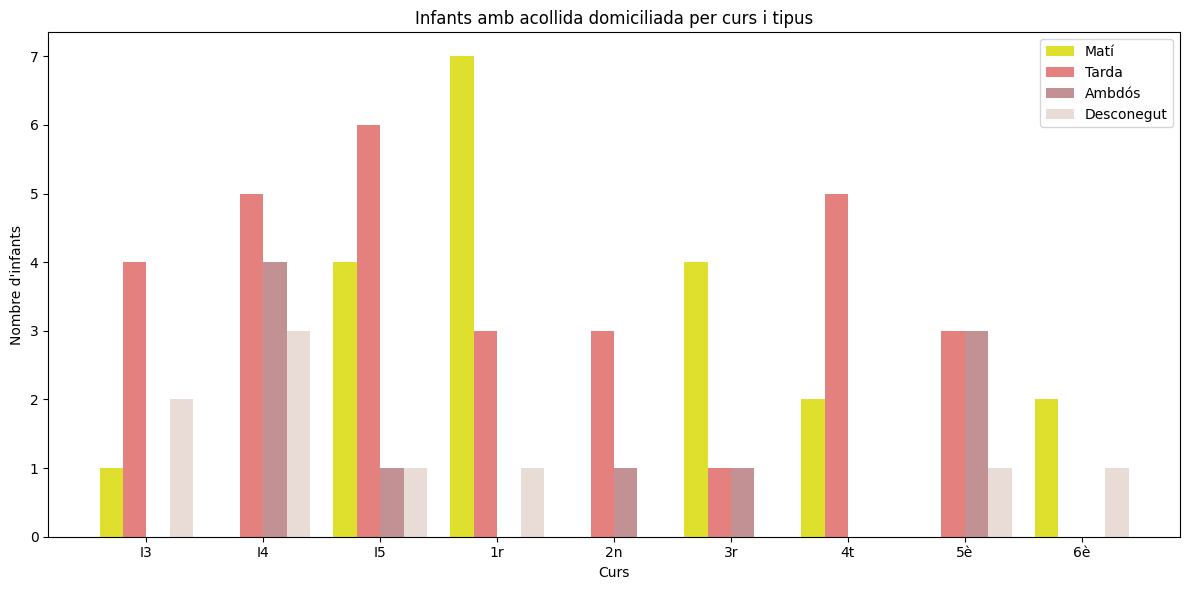

In [544]:
# recordem les columnes de la taula acollida
# list(sprint_10_roser_bbdd_afa_sql_a_python['acollida_anonimitzat'].columns)
# print(acollida['mensual_mati'].unique())
# print(acollida['mensual_tarda'].unique())


# Copiem el dataframe acollida
acollida_amb_tipus = sprint_10_roser_bbdd_afa_sql_a_python['acollida_restringit'].copy()

# Creem una funció que classifica el tipus d'acollida. Hi ha strings buits que són falsos empty.  
def classify_acollida(row):
    mati = row['mensual_mati']
    tarda = row['mensual_tarda']
    
    # Els strings buits els classifiquem com a 'Desconegut'
    if mati == '' and tarda == '':
        return 'Desconegut'
    elif mati != '' and tarda != '':
        return 'Ambdós'
    elif mati != '':
        return 'Matí'
    elif tarda != '':
        return 'Tarda'
    else:
        return 'Desconegut'

# Apliquem la classificació al nostre dataframe
acollida_amb_tipus['tipus_acollida'] = acollida_amb_tipus.apply(classify_acollida, axis=1)


# Agrupem per a obtenir el nombres
acollida_amb_tipus_agrupat = acollida_amb_tipus.groupby(['curs', 'tipus_acollida']).size().reset_index(name='num_infants')
acollida_amb_tipus_agrupat.columns = ['curs', 'tipus_acollida', 'num_infants']

# Apliquem la estandarització a la columna curs
acollida_amb_tipus_agrupat['curs'] = acollida_amb_tipus_agrupat['curs'].map(cursos_estandar).fillna(acollida_amb_tipus_agrupat['curs'])


# Pivotem per a tenir el recompte de tipus d'acollida per cada curs
acollida_amb_tipus_agrupat_pivoted = acollida_amb_tipus_agrupat.pivot(index='curs', columns='tipus_acollida', values='num_infants').fillna(0)

# Definim l'ordre de les categories per al tipus d'acollida
ordered_categories = ['Matí', 'Tarda', 'Ambdós', 'Desconegut']

# Reordenem les columes de la taula pivotadada per a que les categories estiguin en l'ordre que volem
acollida_amb_tipus_agrupat_pivoted = acollida_amb_tipus_agrupat_pivoted[ordered_categories]


# Reordenem els cursos per a que apareguin en l'ordre d'edat
# ordre_cursos = ['I3', 'I4', 'I5', '1r', '2n', '3r', '4t', '5è', '6è', '1r ESO', '2n ESO', '3r ESO', '4t ESO'] l'hem definit abans i no cal
acollida_amb_tipus_agrupat_pivoted = acollida_amb_tipus_agrupat_pivoted.reindex(ordre_cursos).dropna(how='all')



# Grafiquem
x = np.arange(len(acollida_amb_tipus_agrupat_pivoted))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))

# Definim amb els color corporatius de l'AFA
colors = {
    'Matí': '#DFE02Eff',
    'Tarda': '#E4817Fff',
    'Ambdós': '#C19194ff',
    'Desconegut': '#E9DBD5ff'
}

# Plot dynamically??
for i, col in enumerate(acollida_amb_tipus_agrupat_pivoted.columns):
    ax.bar(x + (i - 1.5) * width, acollida_amb_tipus_agrupat_pivoted[col], width, label=col, color=colors.get(col, 'gray'))

ax.set_xlabel('Curs')
ax.set_ylabel("Nombre d\'infants")
ax.set_title("Infants amb acollida domiciliada per curs i tipus")
ax.set_xticks(x)
ax.set_xticklabels(acollida_amb_tipus_agrupat_pivoted.index)
ax.legend()

plt.tight_layout()
plt.savefig("acollida_mati_tarda.png", dpi=300)
plt.show()


### Extraescolars: anàlisi individual

Ara graficarem cada extraescolar individualment. Intentem contar-los tots, també els que tenen id_infant, és a dir, que no han compartit les dades amb TokApp.

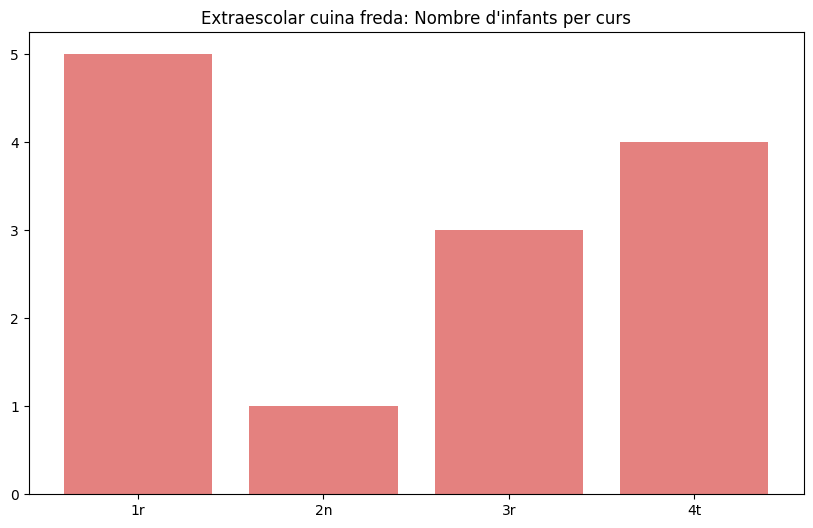

In [545]:
cuinafreda_cursos = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_cuinafreda_2425'].groupby(['curs']).size().reset_index(name='num_infants')

cuinafreda_cursos.columns = ['curs', 'num_infants']

# Apliquem la estandarització a la columna curs
cuinafreda_cursos['curs'] = cuinafreda_cursos['curs'].map(cursos_estandar).fillna(cuinafreda_cursos['curs'])

# Forcem l'ordre dels cursos d'infants més petits a més grans
cuinafreda_cursos['curs'] = pd.Categorical(cuinafreda_cursos['curs'], categories=ordre_cursos, ordered=True) # Aqui ens assegurem que 'curs' està en l'ordre categòric correcte
cuinafreda_cursos = cuinafreda_cursos.sort_values('curs') # Roendem el dataframe per la columna 'curs' per a que estigui en l'ordre correcte

plt.figure(figsize=(10, 6))
plt.bar(cuinafreda_cursos['curs'], cuinafreda_cursos['num_infants'], color='#E4817Fff')
plt.title('Extraescolar cuina freda: Nombre d\'infants per curs')
plt.show()



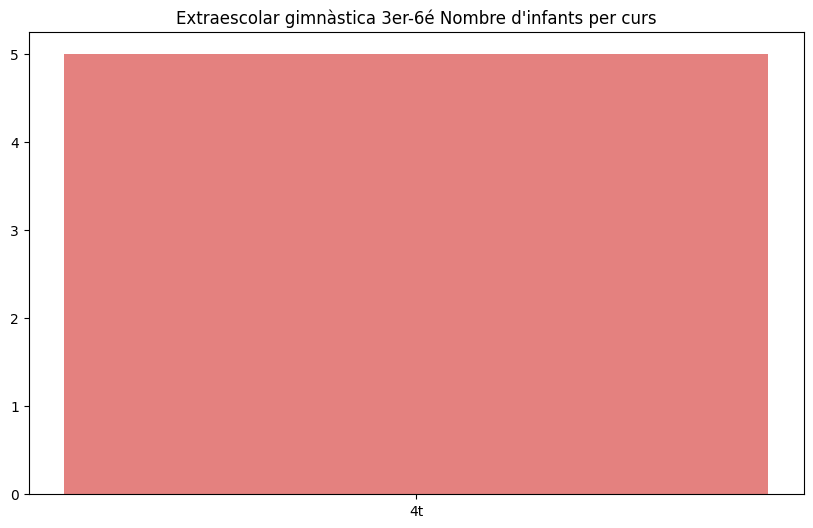

In [546]:
gim_36_cursos = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_gim_36_2425'].groupby(['curs']).size().reset_index(name='num_infants')
gim_36_cursos.columns = ['curs', 'num_infants']

# Apliquem la estandarització a la columna curs
gim_36_cursos['curs'] = gim_36_cursos['curs'].map(cursos_estandar).fillna(gim_36_cursos['curs'])

# Forcem l'ordre dels cursos d'infants més petits a més grans
gim_36_cursos['curs'] = pd.Categorical(gim_36_cursos['curs'], categories=ordre_cursos, ordered=True) # Aqui ens assegurem que 'curs' està en l'ordre categòric correcte
gim_36_cursos = gim_36_cursos.sort_values('curs') # Roendem el dataframe per la columna 'curs' per a que estigui en l'ordre correcte
 

plt.figure(figsize=(10, 6))
plt.bar(gim_36_cursos['curs'], gim_36_cursos['num_infants'], color='#E4817Fff')
plt.title('Extraescolar gimnàstica 3er-6é Nombre d\'infants per curs')
plt.show()

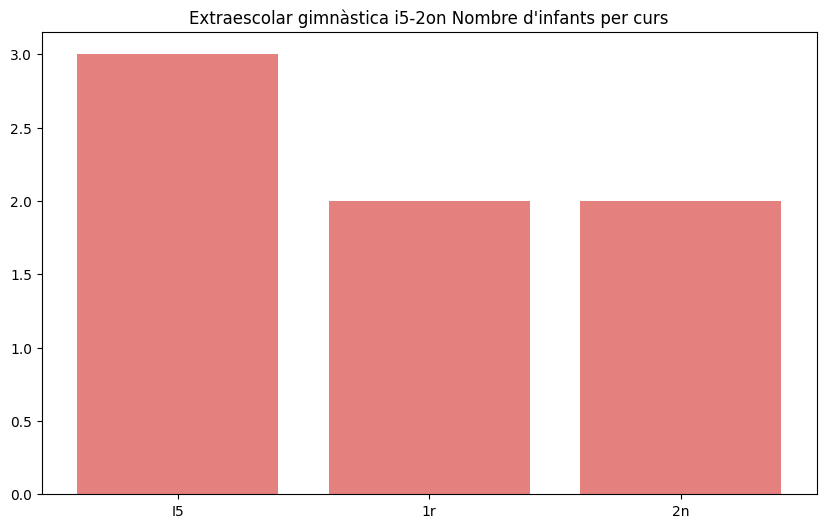

In [547]:
gim_i52_cursos = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_gim_i52_2425'].groupby(['curs']).size().reset_index(name='num_infants')
gim_i52_cursos.columns = ['curs', 'num_infants']

# Apliquem la estandarització a la columna curs
gim_i52_cursos['curs'] = gim_i52_cursos['curs'].map(cursos_estandar).fillna(gim_i52_cursos['curs'])


# Forcem l'ordre dels cursos d'infants més petits a més grans 
gim_i52_cursos['curs'] = pd.Categorical(gim_i52_cursos['curs'], categories=ordre_cursos, ordered=True) # Aqui ens assegurem que 'curs' està en l'ordre categòric correcte
gim_i52_cursos = gim_i52_cursos.sort_values('curs') # Roendem el dataframe per la columna 'curs' per a que estigui en l'ordre correcte



plt.figure(figsize=(10, 6))
plt.bar(gim_i52_cursos['curs'], gim_i52_cursos['num_infants'], color='#E4817Fff')
plt.title('Extraescolar gimnàstica i5-2on Nombre d\'infants per curs')
plt.show()

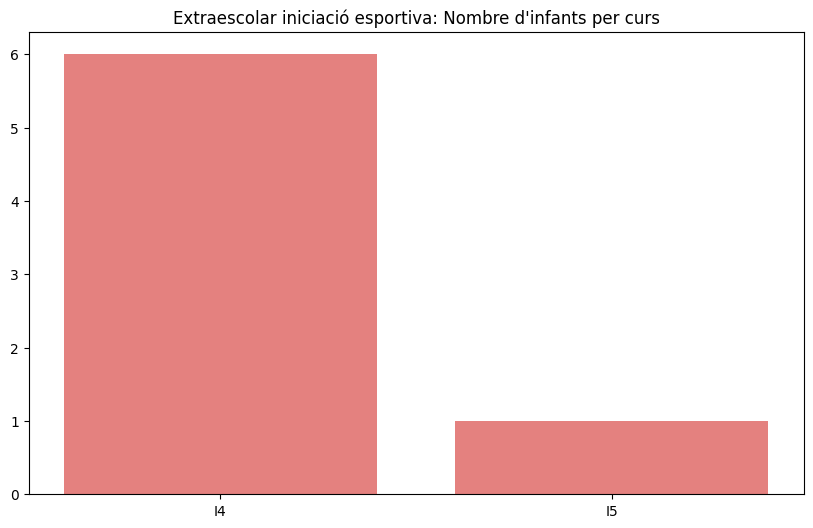

In [548]:
iesportiva_cursos = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_iesportiva_2425'].groupby(['curs']).size().reset_index(name='num_infants')
iesportiva_cursos.columns = ['curs', 'num_infants']

# Apliquem la estandarització a la columna curs
iesportiva_cursos['curs'] = iesportiva_cursos['curs'].map(cursos_estandar).fillna(iesportiva_cursos['curs'])

# Forcem l'ordre dels cursos d'infants més petits a més grans
iesportiva_cursos['curs'] = pd.Categorical(iesportiva_cursos['curs'], categories=ordre_cursos, ordered=True) # Aqui ens assegurem que 'curs' està en l'ordre categòric correcte
iesportiva_cursos = iesportiva_cursos.sort_values('curs') # Roendem el dataframe per la columna 'curs' per a que estigui en l'ordre correcte

plt.figure(figsize=(10, 6))
plt.bar(iesportiva_cursos['curs'], iesportiva_cursos['num_infants'], color='#E4817Fff')
plt.title('Extraescolar iniciació esportiva: Nombre d\'infants per curs')
plt.show()

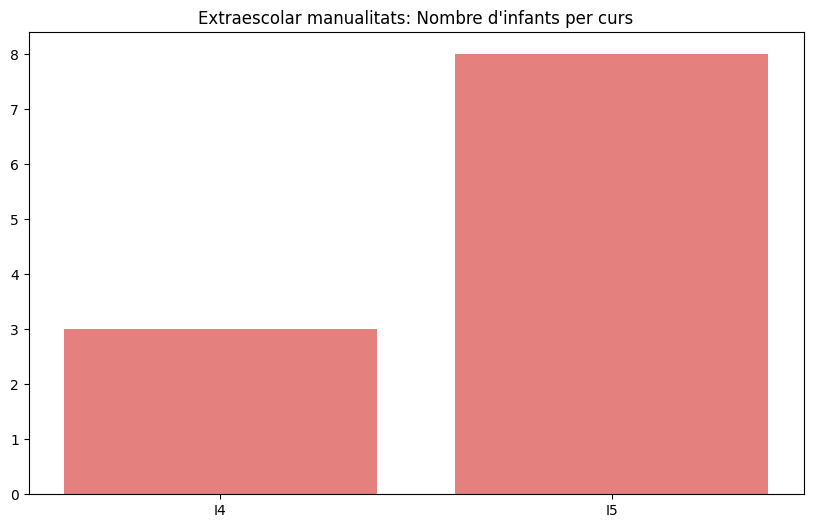

In [549]:
manualitats_cursos = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_manualitats_2425'].groupby(['curs']).size().reset_index(name='num_infants')
manualitats_cursos.columns = ['curs', 'num_infants']

# Apliquem la estandarització a la columna curs
manualitats_cursos['curs'] = manualitats_cursos['curs'].map(cursos_estandar).fillna(manualitats_cursos['curs'])

# Forcem l'ordre dels cursos d'infants més petits a més grans
manualitats_cursos['curs'] = pd.Categorical(manualitats_cursos['curs'], categories=ordre_cursos, ordered=True) # Aqui ens assegurem que 'curs' està en l'ordre categòric correcte
manualitats_cursos = manualitats_cursos.sort_values('curs') # Roendem el dataframe per la columna 'curs' per a que estigui en l'ordre correcte

plt.figure(figsize=(10, 6))
plt.bar(manualitats_cursos['curs'], manualitats_cursos['num_infants'], color='#E4817Fff')
plt.title('Extraescolar manualitats: Nombre d\'infants per curs')
plt.show()

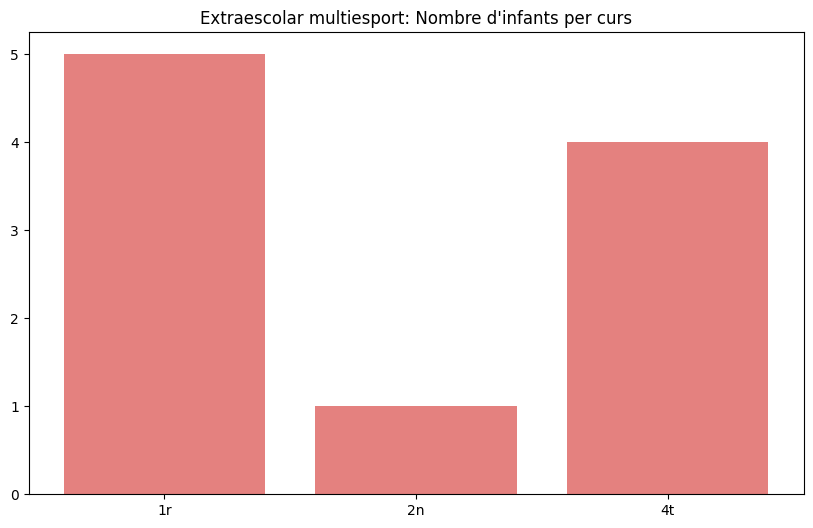

In [550]:
multiesport_cursos = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_multiesport_2425'].groupby(['curs']).size().reset_index(name='num_infants')
multiesport_cursos.columns = ['curs', 'num_infants']

# Apliquem la estandarització a la columna curs
multiesport_cursos['curs'] = multiesport_cursos['curs'].map(cursos_estandar).fillna(multiesport_cursos['curs'])

# Forcem l'ordre dels cursos d'infants més petits a més grans
multiesport_cursos['curs'] = pd.Categorical(multiesport_cursos['curs'], categories=ordre_cursos, ordered=True) # Aqui ens assegurem que 'curs' està en l'ordre categòric correcte
multiesport_cursos = multiesport_cursos.sort_values('curs') # Roendem el dataframe per la columna 'curs' per a que estigui en l'ordre correcte


plt.figure(figsize=(10, 6))
plt.bar(multiesport_cursos['curs'], multiesport_cursos['num_infants'], color='#E4817Fff')
plt.title('Extraescolar multiesport: Nombre d\'infants per curs')
plt.show()

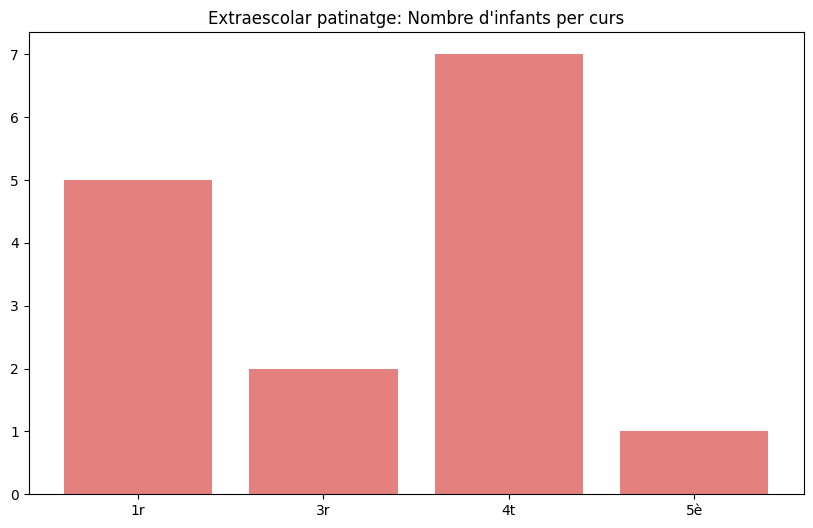

In [551]:
patinatge_cursos = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_patinatge_2425'].groupby(['curs']).size().reset_index(name='num_infants')
patinatge_cursos.columns = ['curs', 'num_infants']

# Apliquem la estandarització a la columna curs
patinatge_cursos['curs'] = patinatge_cursos['curs'].map(cursos_estandar).fillna(patinatge_cursos['curs'])

# Forcem l'ordre dels cursos d'infants més petits a més grans
patinatge_cursos['curs'] = pd.Categorical(patinatge_cursos['curs'], categories=ordre_cursos, ordered=True) # Aqui ens assegurem que 'curs' està en l'ordre categòric correcte
patinatge_cursos = patinatge_cursos.sort_values('curs') # Roendem el dataframe per la columna 'curs' per a que estigui en l'ordre correcte

plt.figure(figsize=(10, 6))
plt.bar(patinatge_cursos['curs'], patinatge_cursos['num_infants'], color='#E4817Fff')
plt.title('Extraescolar patinatge: Nombre d\'infants per curs')
plt.show()

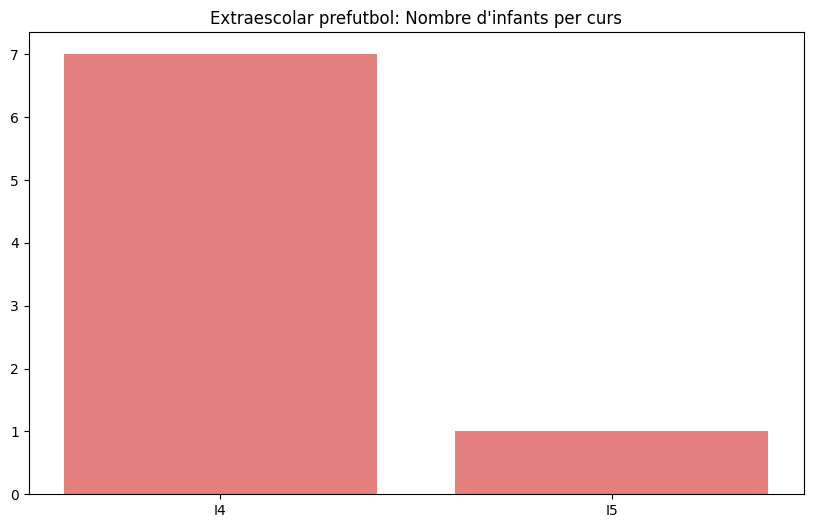

In [552]:
prefutbol_cursos = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_prefutbol_2425'].groupby(['curs']).size().reset_index(name='num_infants')
prefutbol_cursos.columns = ['curs', 'num_infants']

# Apliquem la estandarització a la columna curs
prefutbol_cursos['curs'] = prefutbol_cursos['curs'].map(cursos_estandar).fillna(prefutbol_cursos['curs'])

# Forcem l'ordre dels cursos d'infants més petits a més grans
prefutbol_cursos['curs'] = pd.Categorical(prefutbol_cursos['curs'], categories=ordre_cursos, ordered=True) # Aqui ens assegurem que 'curs' està en l'ordre categòric correcte
prefutbol_cursos = prefutbol_cursos.sort_values('curs') # Roendem el dataframe per la columna 'curs' per a que estigui en l'ordre correcte

plt.figure(figsize=(10, 6))
plt.bar(prefutbol_cursos['curs'], prefutbol_cursos['num_infants'], color='#E4817Fff')
plt.title('Extraescolar prefutbol: Nombre d\'infants per curs')
plt.show()

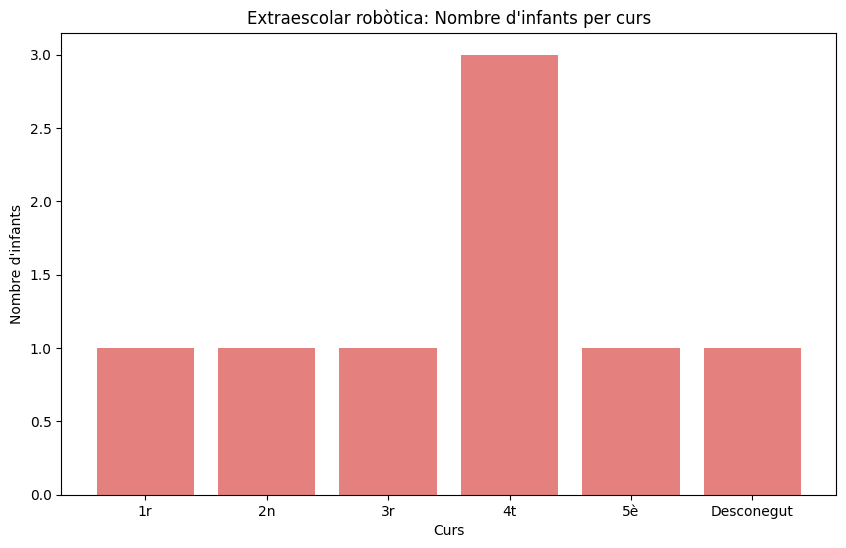

In [553]:
robotica_cursos = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_robotica_2425'].groupby(['curs']).size().reset_index(name='num_infants')
robotica_cursos.columns = ['curs', 'num_infants']

# Apliquem la estandarització a la columna curs
robotica_cursos['curs'] = robotica_cursos['curs'].map(cursos_estandar).fillna(robotica_cursos['curs'])

# Forcem l'ordre dels cursos d'infants més petits a més grans
robotica_cursos['curs'] = pd.Categorical(robotica_cursos['curs'], categories=ordre_cursos, ordered=True) # Aqui ens assegurem que 'curs' està en l'ordre categòric correcte
robotica_cursos = robotica_cursos.sort_values('curs') # Roendem el dataframe per la columna 'curs' per a que estigui en l'ordre correcte


plt.figure(figsize=(10, 6))
plt.bar(robotica_cursos['curs'], robotica_cursos['num_infants'], color='#E4817Fff')
plt.title('Extraescolar robòtica: Nombre d\'infants per curs')
plt.ylabel('Nombre d\'infants')
plt.xlabel('Curs')
plt.show()

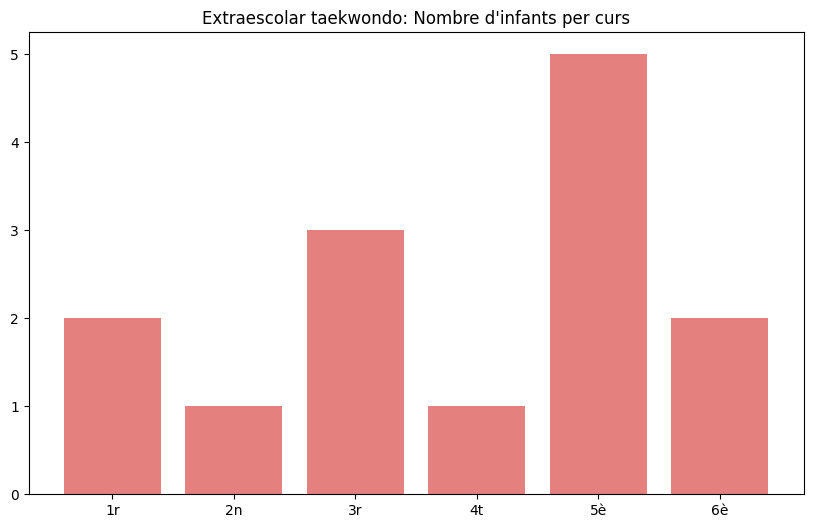

In [554]:
taekwondo_cursos = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_taekwondo_2425'].groupby(['curs']).size().reset_index(name='num_infants')
taekwondo_cursos.columns = ['curs', 'num_infants']

# Apliquem la estandarització a la columna curs
taekwondo_cursos['curs'] = taekwondo_cursos['curs'].map(cursos_estandar).fillna(taekwondo_cursos['curs'])

# Forcem l'ordre dels cursos d'infants més petits a més grans
taekwondo_cursos['curs'] = pd.Categorical(taekwondo_cursos['curs'], categories=ordre_cursos, ordered=True) # Aqui ens assegurem que 'curs' està en l'ordre categòric correcte
taekwondo_cursos = taekwondo_cursos.sort_values('curs') # Roendem el dataframe per la columna 'curs' per a que estigui en l'ordre correcte

plt.figure(figsize=(10, 6))
plt.bar(taekwondo_cursos['curs'], taekwondo_cursos['num_infants'], color='#E4817Fff')
plt.title('Extraescolar taekwondo: Nombre d\'infants per curs')
plt.show()

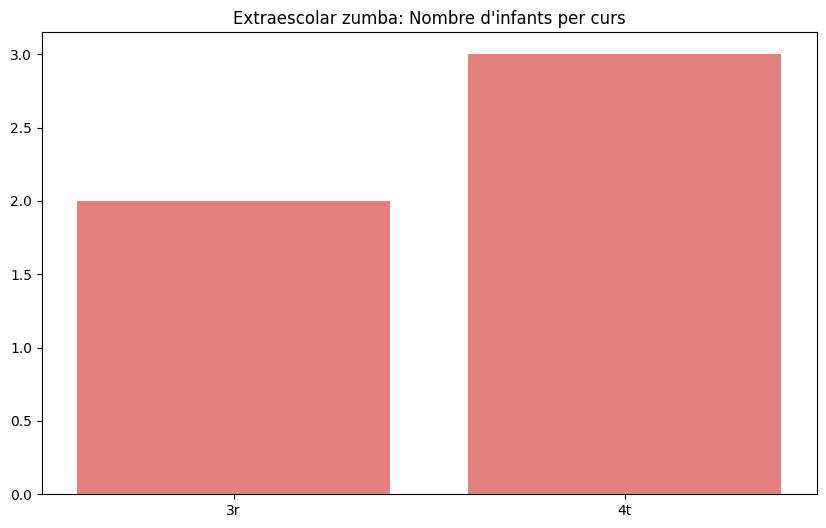

In [555]:
zumba_cursos = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_zumba_2425'].groupby(['curs']).size().reset_index(name='num_infants')
zumba_cursos.columns = ['curs', 'num_infants']

# Apliquem la estandarització a la columna curs
zumba_cursos['curs'] = zumba_cursos['curs'].map(cursos_estandar).fillna(zumba_cursos['curs'])

# Forcem l'ordre dels cursos d'infants més petits a més grans
zumba_cursos['curs'] = pd.Categorical(zumba_cursos['curs'], categories=ordre_cursos, ordered=True) # Aqui ens assegurem que 'curs' està en l'ordre categòric correcte
zumba_cursos = zumba_cursos.sort_values('curs') # Roendem el dataframe per la columna 'curs' per a que estigui en l'ordre correcte

plt.figure(figsize=(10, 6))
plt.bar(zumba_cursos['curs'], zumba_cursos['num_infants'], color='#E4817Fff')
plt.title('Extraescolar zumba: Nombre d\'infants per curs')
plt.show()

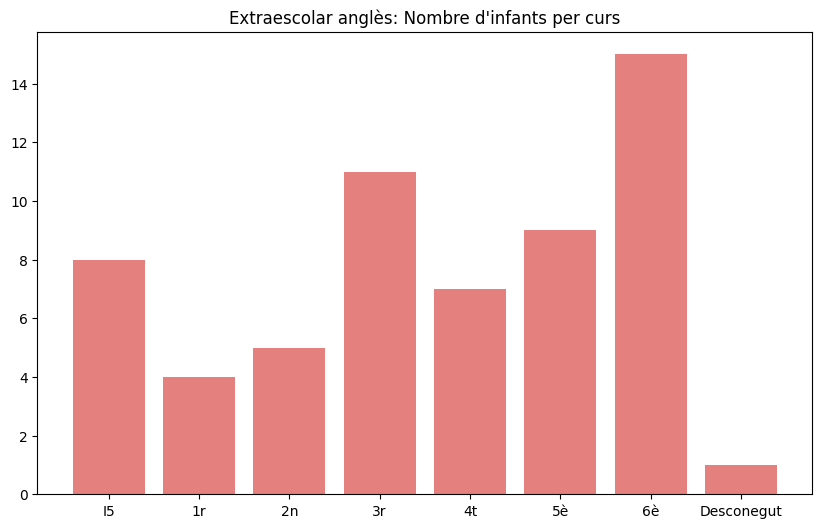

In [556]:
angles_cursos = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_angles_2425'].groupby(['curs']).size().reset_index(name='num_infants')
angles_cursos.columns = ['curs', 'num_infants']

# Apliquem la estandarització a la columna curs
angles_cursos['curs'] = angles_cursos['curs'].map(cursos_estandar).fillna(angles_cursos['curs'])

# Forcem l'ordre dels cursos d'infants més petits a més grans
angles_cursos['curs'] = pd.Categorical(angles_cursos['curs'], categories=ordre_cursos, ordered=True) # Aqui ens assegurem que 'curs' està en l'ordre categòric correcte
angles_cursos = angles_cursos.sort_values('curs') # Roendem el dataframe per la columna 'curs' per a que estigui en l'ordre correcte

plt.figure(figsize=(10, 6))
plt.bar(angles_cursos['curs'], angles_cursos['num_infants'], color='#E4817Fff')
plt.title('Extraescolar anglès: Nombre d\'infants per curs')
plt.savefig("angles_per_curs.png", dpi=300)
plt.show()

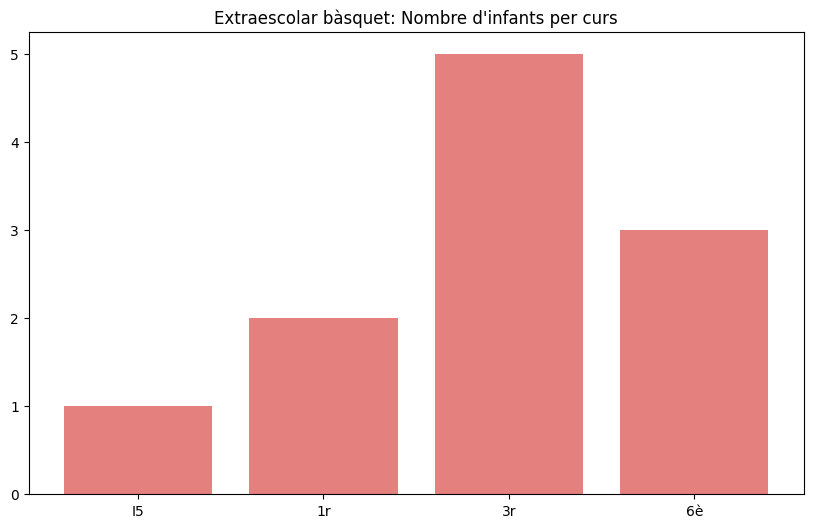

In [557]:
# La de bàsquet la podem fer en base al id perquè tots els infants tenen id i a més, així eliminem els duplicats perquè aquí hi ha dues fileres si van dos dies a la setmana
basquet_cursos = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_basquet_2425'].groupby(['curs'])['id_infant'].count().reset_index()
basquet_cursos.columns = ['curs', 'num_infants']

# Apliquem la estandarització a la columna curs
basquet_cursos['curs'] = basquet_cursos['curs'].map(cursos_estandar).fillna(basquet_cursos['curs'])

# Forcem l'ordre dels cursos d'infants més petits a més grans
basquet_cursos['curs'] = pd.Categorical(basquet_cursos['curs'], categories=ordre_cursos, ordered=True) # Aqui ens assegurem que 'curs' està en l'ordre categòric correcte
basquet_cursos = basquet_cursos.sort_values('curs') # Roendem el dataframe per la columna 'curs' per a que estigui en l'ordre correcte

plt.figure(figsize=(10, 6))
plt.bar(basquet_cursos['curs'], basquet_cursos['num_infants'], color='#E4817Fff')
plt.title('Extraescolar bàsquet: Nombre d\'infants per curs')
plt.show()

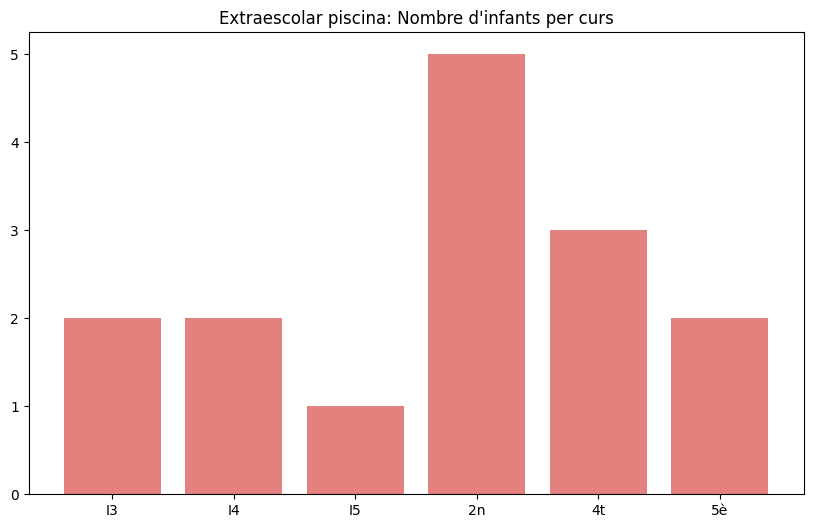

In [567]:
piscina_cursos = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_piscina_2425'].groupby(['curs']).size().reset_index(name='num_infants')
piscina_cursos.columns = ['curs', 'num_infants']

# Apliquem la estandarització a la columna curs
piscina_cursos['curs'] = piscina_cursos['curs'].map(cursos_estandar).fillna(piscina_cursos['curs'])

# Forcem l'ordre dels cursos d'infants més petits a més grans
piscina_cursos['curs'] = pd.Categorical(piscina_cursos['curs'], categories=ordre_cursos, ordered=True) # Aqui ens assegurem que 'curs' està en l'ordre categòric correcte
piscina_cursos = piscina_cursos.sort_values('curs') # Roendem el dataframe per la columna 'curs' per a que estigui en l'ordre correcte

plt.figure(figsize=(10, 6))
plt.bar(piscina_cursos['curs'], piscina_cursos['num_infants'], color='#E4817Fff')
plt.title('Extraescolar piscina: Nombre d\'infants per curs')
plt.savefig("piscina_infants.png", dpi=300)
plt.show()

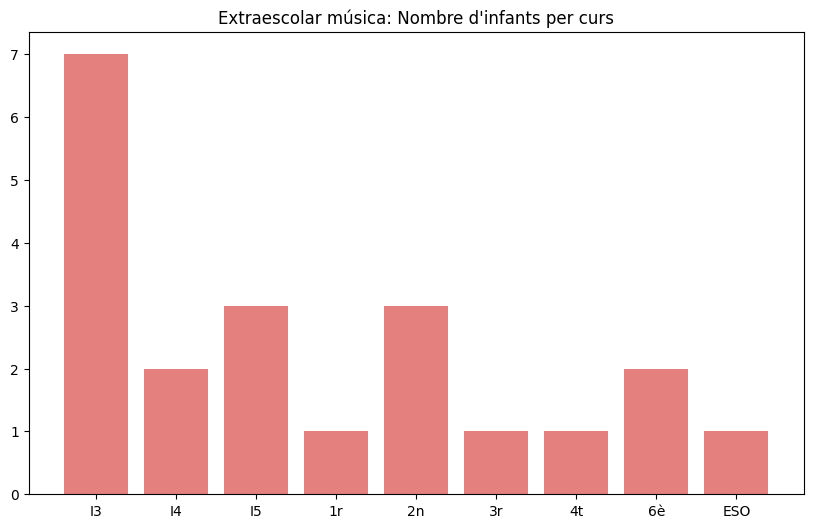

In [559]:
musica_cursos = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_musica_2425'].groupby(['curs']).size().reset_index(name='num_infants')
musica_cursos.columns = ['curs', 'num_infants']

# Apliquem la estandarització a la columna curs
musica_cursos['curs'] = musica_cursos['curs'].map(cursos_estandar).fillna(musica_cursos['curs'])

# Forcem l'ordre dels cursos d'infants més petits a més grans
musica_cursos['curs'] = pd.Categorical(musica_cursos['curs'], categories=ordre_cursos, ordered=True) # Aqui ens assegurem que 'curs' està en l'ordre categòric correcte
musica_cursos = musica_cursos.sort_values('curs') # Roendem el dataframe per la columna 'curs' per a que estigui en l'ordre correcte


plt.figure(figsize=(10, 6))
plt.bar(musica_cursos['curs'], musica_cursos['num_infants'], color='#E4817Fff')
plt.title('Extraescolar música: Nombre d\'infants per curs')
plt.show()

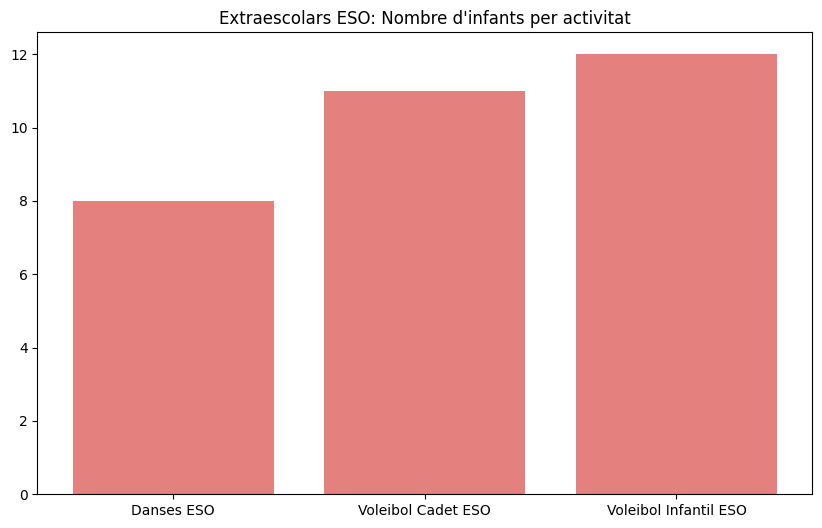

In [560]:
eso_cursos = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_eso_2425'].groupby(['curs']).size().reset_index(name='num_infants')
eso_cursos.columns = ['curs', 'num_infants']


plt.figure(figsize=(10, 6))
plt.bar(eso_cursos['curs'], eso_cursos['num_infants'], color='#E4817Fff')
plt.title('Extraescolars ESO: Nombre d\'infants per activitat')
plt.show()

### Extraescolars: anàlisi conjunt

Ara volem saber comparar totes les extraescolars juntes 

In [561]:
# Primer farem uns canvis en la taula de la ESO
# Canviarem el nom de la columna 'curs' que en realitat és una 'activitat'
sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_eso_2425'] = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_eso_2425'].rename(columns={'curs': 'activitat'})

# Afegirem una nova columna 'curs' amb el valor 'ESO' per a tots
sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_eso_2425']['curs'] = 'ESO'

sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_eso_2425']

,nom_complet,activitat,id_infant,estatus_socis,curs
0,MARTINA ESPINAR DELGADO,Voleibol Cadet ESO,NaN,No Socis,ESO
1,JULIETTE FORTRIE GIRALT,Voleibol Cadet ESO,774.0,Soci,ESO
2,GEMMA GARCIA ALDEA,Voleibol Cadet ESO,726.0,No Socis,ESO
3,AINARA DURAN CUELLAR,Voleibol Cadet ESO,NaN,No Socis,ESO
4,JÚLIA CAMPS CABEDO,Voleibol Cadet ESO,NaN,No Socis,ESO
5,SARA LANAU GONZALEZ,Voleibol Cadet ESO,NaN,No Socis,ESO
6,HÉCTOR PARRÓN CASTRO,Voleibol Cadet ESO,NaN,No Socis,ESO
7,JESUS SÁNCHEZ MARTÍNEZ,Voleibol Cadet ESO,NaN,No Socis,ESO
8,ALBA GIMÉNEZ GARCÍA,Voleibol Cadet ESO,NaN,No Socis,ESO
9,QUERALT RUIZ CASES,Voleibol Cadet ESO,NaN,No Socis,ESO


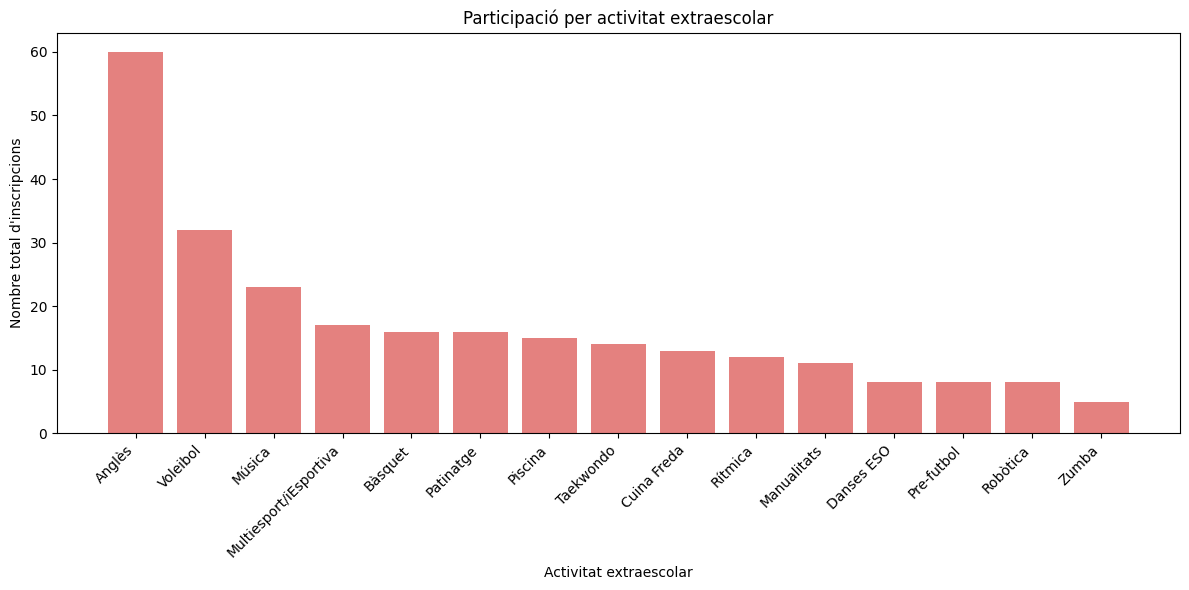

In [ ]:
# list(sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_angles_2425'].columns)

# Preparem totes les taules manualment afegint-los una columna d'activitat
angles = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_angles_2425'][['id_infant', 'curs']].copy()
angles['activitat'] = 'Anglès'

basquet = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_basquet_2425'][['id_infant', 'curs']].copy()
basquet['activitat'] = 'Bàsquet'

cuina = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_cuinafreda_2425'][['id_infant', 'curs']].copy()
cuina['activitat'] = 'Cuina Freda'

eso = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_eso_2425'][['id_infant', 'curs','activitat']].copy()

gim36 = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_gim_36_2425'][['id_infant', 'curs']].copy()
gim36['activitat'] = 'Rítmica'

gim52 = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_gim_i52_2425'][['id_infant', 'curs']].copy()
gim52['activitat'] = 'Rítmica'

esportiva = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_iesportiva_2425'][['id_infant', 'curs']].copy()
esportiva['activitat'] = 'Multiesport/iEsportiva'

manualitats = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_manualitats_2425'][['id_infant', 'curs']].copy()
manualitats['activitat'] = 'Manualitats'

multi = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_multiesport_2425'][['id_infant', 'curs']].copy()
multi['activitat'] = 'Multiesport/iEsportiva'

musica = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_musica_2425'][['id_infant', 'curs']].copy()
musica['activitat'] = 'Música'

patinatge = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_patinatge_2425'][['id_infant', 'curs']].copy()
patinatge['activitat'] = 'Patinatge'

piscina = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_piscina_2425'][['id_infant', 'curs']].copy()
piscina['activitat'] = 'Piscina'

prefutbol = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_prefutbol_2425'][['id_infant', 'curs']].copy()
prefutbol['activitat'] = 'Pre-futbol'

robotica = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_robotica_2425'][['id_infant', 'curs']].copy()
robotica['activitat'] = 'Robòtica'

taekwondo = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_taekwondo_2425'][['id_infant', 'curs']].copy()
taekwondo['activitat'] = 'Taekwondo'

volei = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_voleiprimaria_2425'][['id_infant', 'curs']].copy()
volei['activitat'] = 'Volei Primària'

zumba = sprint_10_roser_bbdd_afa_sql_a_python['extraescolar_zumba_2425'][['id_infant', 'curs']].copy()
zumba['activitat'] = 'Zumba'

# Concatenem en un sol dataframe 
all_activities_df = pd.concat([
    angles, basquet, cuina, eso, gim36, gim52, esportiva, manualitats,
    multi, musica, patinatge, piscina, prefutbol, robotica,
    taekwondo, volei, zumba
], ignore_index=True)

# List unique activity names that contain "volei" (case-insensitive)
# volei_related = all_activities_df['activitat'].unique()
# [act for act in volei_related if 'volei' in act.lower()]

# Standaritzem el nom de totes les activitats de volei 
all_activities_df['activitat'] = all_activities_df['activitat'].replace({
    'Voleibol Cadet ESO': 'Voleibol',
    'Voleibol Infantil ESO': 'Voleibol',
    'Volei Primària': 'Voleibol'
})


# Group by activity and count unique id_infant
# activity_counts = all_activities_df.groupby('activitat')['id_infant'].nunique().reset_index()
# activity_counts = activity_counts.sort_values('id_infant', ascending=False)

# Agrupem per activitat però volem contar tots, incluent els que tenen id_infant null or buit)
activity_counts = all_activities_df.groupby('activitat').size().reset_index(name='num_infants')
activity_counts = activity_counts.sort_values('num_infants', ascending=False)



# Grafiquem
plt.figure(figsize=(12, 6))
plt.bar(activity_counts['activitat'], activity_counts['num_infants'], color='#E4817F')
plt.xlabel('Activitat extraescolar')
plt.ylabel('Nombre total d\'inscripcions')
plt.title('Participació per activitat extraescolar')
plt.xticks(rotation=45, ha='right')
plt.savefig("participacio_per_estraescolar.png", dpi=300)
plt.tight_layout()
plt.show()

In [563]:
activity_counts

,activitat,num_infants
0,Anglès,60
13,Voleibol,32
6,Música,23
5,Multiesport/iEsportiva,17
1,Bàsquet,16
7,Patinatge,16
8,Piscina,15
12,Taekwondo,14
2,Cuina Freda,13
11,Rítmica,12


Quantes famílies sòcies fan servir acollida o extraescolars?

La taula taula_anonimitzada té dades de 
id_familia
estatus_socis
id_infant

La taula de sprint_10_roser_bbdd_afa_sql_a_python['acollida_anonimitzat'] 
té els ids dels infants en acollida
 
La taula all_activities_df té les columnes 'id_infant', 'curs', 'activitat'

### Extraescolars: anàlisi per curs

Ara volem veure les inscripcions en extraescolars per curs. 

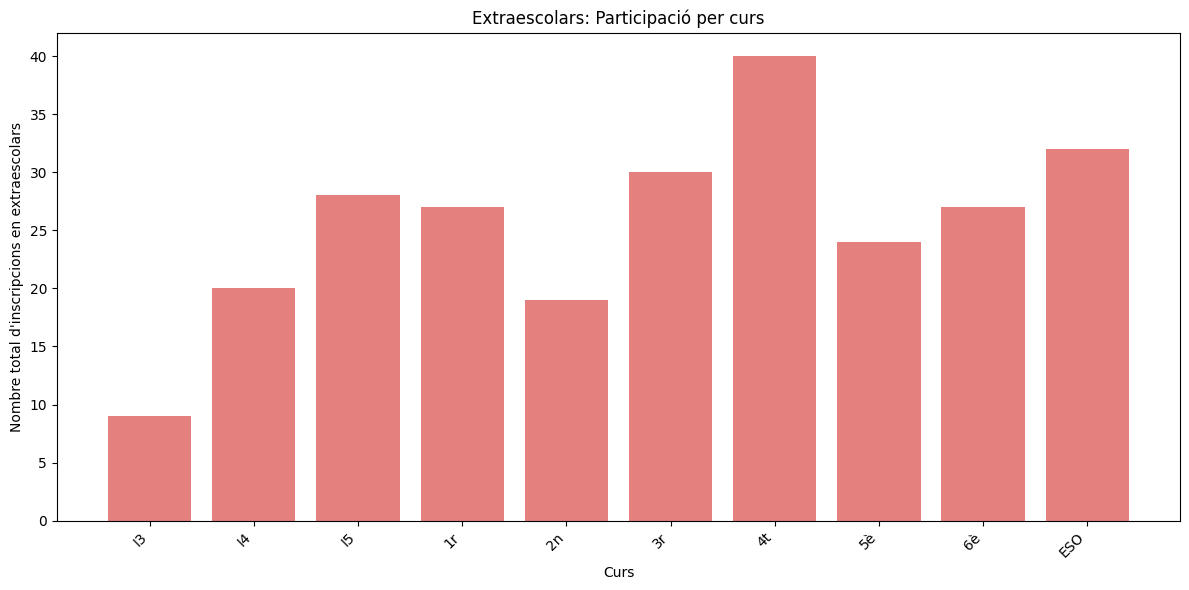

In [564]:
# Estandaritzem el nom del curs
all_activities_df['curs'] = all_activities_df['curs'].map(cursos_estandar).fillna('Desconegut')

# Agrupem i contem
cursos_counts_norm = all_activities_df.groupby('curs').size().reset_index(name='num_infants')

# Forcem l'ordre categoric
cursos_counts_norm['curs'] = pd.Categorical(
    cursos_counts_norm['curs'],
    categories=ordre_cursos,
    ordered=True
)

# Treiem els cursos desconegits i buits abans de graficar
cursos_counts_norm = cursos_counts_norm[cursos_counts_norm['curs'].notna()]
cursos_counts_norm = cursos_counts_norm[cursos_counts_norm['curs'] != 'Desconegut']

# Ordenem per curs
cursos_counts_norm = cursos_counts_norm.sort_values('curs')

# Grafiquem
plt.figure(figsize=(12, 6))
plt.bar(cursos_counts_norm['curs'].astype(str), cursos_counts_norm['num_infants'], color='#E4817F')
plt.xlabel('Curs')
plt.ylabel('Nombre total d\'inscripcions en extraescolars')
plt.title('Extraescolars: Participació per curs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("participacio_extraescolar_per_curs.png", dpi=300)
plt.show()


### Acollida + extraescolars per curs

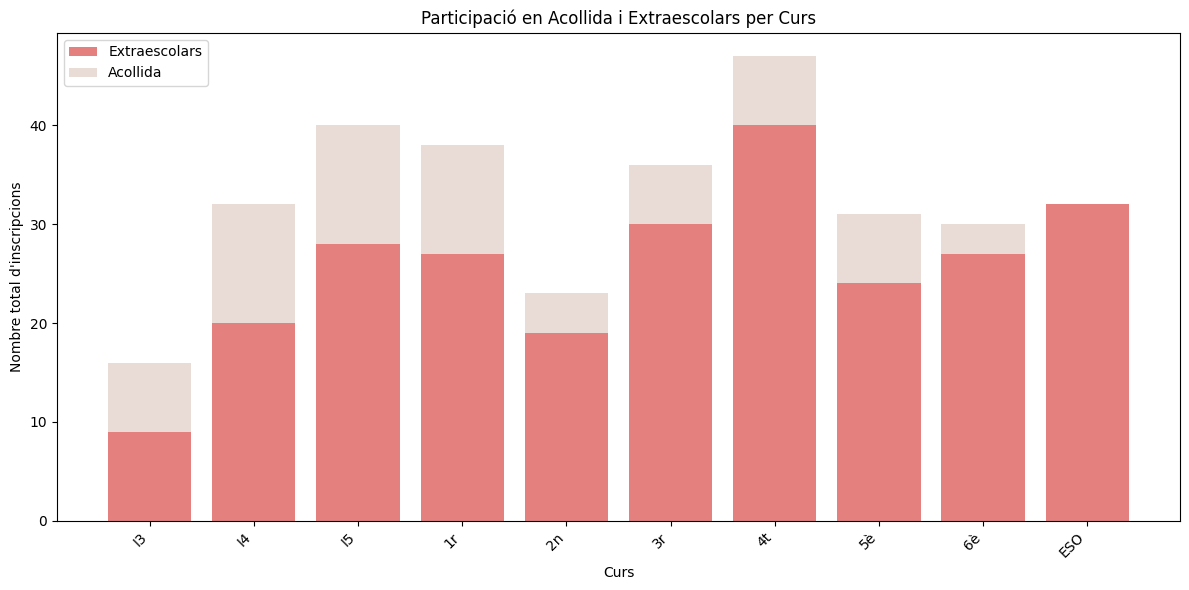

In [565]:
# Canviem els noms de les columnes abans de fer el merge
acollida_cursos.rename(columns={'curs': 'curs_normalized'}, inplace=True)

cursos_counts_norm.rename(columns={'curs': 'curs_normalized'}, inplace=True)


# Unim els df d'extraescolars i d'acollida. Ambdós tenim el curs normalitzat. 
acollida_i_extraescolars_per_cursos = cursos_counts_norm.merge(
    acollida_cursos,
    on='curs_normalized',
    how='outer',
    suffixes=('_extraescolar', '_acollida')
)


# Apliquem la estandarització a la columna curs
acollida_cursos['curs_normalized'] = acollida_cursos['curs_normalized'].map(cursos_estandar).fillna(acollida_cursos['curs_normalized'])

# Fem que el 'curs_normalized' sigui una columna categòrica per a poder ordenar-la 
acollida_i_extraescolars_per_cursos['curs_normalized'] = pd.Categorical(
    acollida_i_extraescolars_per_cursos['curs_normalized'],
    categories=ordre_cursos,
    ordered=True
)

# Demanem que el dataframe estigui ordenat per 'curs_normalized'
acollida_i_extraescolars_per_cursos = acollida_i_extraescolars_per_cursos.sort_values('curs_normalized')


# Grafiquem en barres apilades
plt.figure(figsize=(12, 6))
bar1 = plt.bar(acollida_i_extraescolars_per_cursos['curs_normalized'], acollida_i_extraescolars_per_cursos['num_infants_extraescolar'], label='Extraescolars', color='#E4817Fff')
bar2 = plt.bar(acollida_i_extraescolars_per_cursos['curs_normalized'], acollida_i_extraescolars_per_cursos['num_infants_acollida'], 
               bottom=acollida_i_extraescolars_per_cursos['num_infants_extraescolar'], label='Acollida', color='#E9DBD5ff')


plt.xlabel('Curs')
plt.ylabel('Nombre total d\'inscripcions')
plt.title('Participació en Acollida i Extraescolars per Curs')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()


Sols les tardes

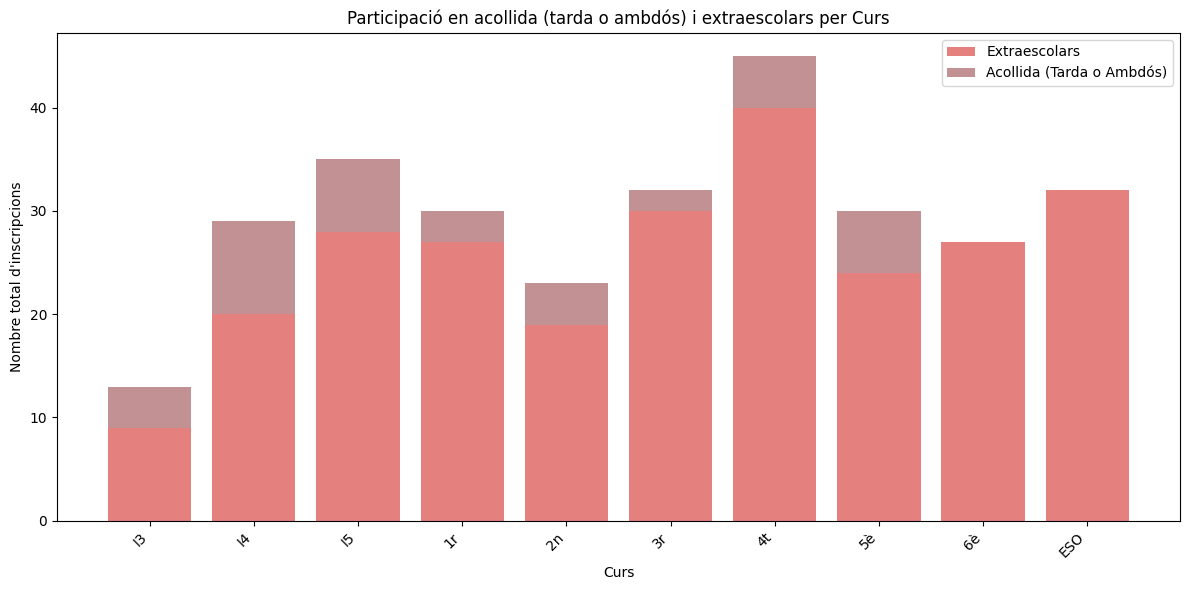

In [566]:
# Filtrem només 'Tarda' i 'Ambdós'
acollida_filtrada = acollida_amb_tipus[acollida_amb_tipus['tipus_acollida'].isin(['Tarda', 'Ambdós'])].copy()

# Contem el número d'infants per 'curs'
acollida_tarda_ambdos = acollida_filtrada.groupby('curs')['id_infant'].count().reset_index()
acollida_tarda_ambdos.columns = ['curs', 'num_infants']

# Normalitzem 'curs' utilitzant els cursos estàndard
acollida_tarda_ambdos['curs_normalized'] = acollida_tarda_ambdos['curs'].map(cursos_estandar).fillna(acollida_tarda_ambdos['curs'])

# Agrupem de nous per al valor normalitzat
acollida_tarda_ambdos = acollida_tarda_ambdos.groupby('curs_normalized')['num_infants'].sum().reset_index()

# Unim amb els cursos normalitzats d'extraescolars
acollida_i_extraescolars_filtrat = cursos_counts_norm.merge(
    acollida_tarda_ambdos,
    on='curs_normalized',
    how='outer',
    suffixes=('_extraescolar', '_acollida')
)

# Plenar NaNs amb 0
acollida_i_extraescolars_filtrat = acollida_i_extraescolars_filtrat.fillna(0)
acollida_i_extraescolars_filtrat['num_infants_extraescolar'] = acollida_i_extraescolars_filtrat['num_infants_extraescolar'].astype(int)
acollida_i_extraescolars_filtrat['num_infants_acollida'] = acollida_i_extraescolars_filtrat['num_infants_acollida'].astype(int)


acollida_i_extraescolars_filtrat['curs_normalized'] = pd.Categorical(
    acollida_i_extraescolars_filtrat['curs_normalized'],
    categories=ordre_cursos,
    ordered=True
)

acollida_i_extraescolars_filtrat = acollida_i_extraescolars_filtrat.sort_values('curs_normalized')

# Grafiquem
plt.figure(figsize=(12, 6))
plt.bar(acollida_i_extraescolars_filtrat['curs_normalized'], acollida_i_extraescolars_filtrat['num_infants_extraescolar'], label='Extraescolars', color='#E4817F')
plt.bar(acollida_i_extraescolars_filtrat['curs_normalized'], acollida_i_extraescolars_filtrat['num_infants_acollida'], 
        bottom=acollida_i_extraescolars_filtrat['num_infants_extraescolar'], label='Acollida (Tarda o Ambdós)', color='#C19194')

plt.xlabel('Curs')
plt.ylabel('Nombre total d\'inscripcions')
plt.title('Participació en acollida (tarda o ambdós) i extraescolars per Curs')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig("tarda_acollida_i_extraescolarr.png", dpi=300)
plt.show()



In [464]:
#  Agafem tots els ids d'acollida i d'extraescolars
infants_acollida = sprint_10_roser_bbdd_afa_sql_a_python['acollida_anonimitzat']['id_infant'].dropna().unique()
infants_activitats = all_activities_df['id_infant'].dropna().unique()

# Combinem els dos sets
infants_combined = set(infants_acollida) | set(infants_activitats)

# Utilitzem la taula anonimitzada d'infants i famílies
taula_anon = taula_anonimitzada

# Filtrem només les files que estan en la llista combinada
famílies_usuaris = taula_anon[taula_anon['id_infant'].isin(infants_combined)]

# I en treiem la llista d'ids de família sense duplicats
famílies_usuaris_uniques = famílies_usuaris['id_familia'].dropna().unique()

# Digue'm el resultat
print(f"Nombre de famílies que utilitzen acollida o activitats: {len(famílies_usuaris_uniques)}")


# Ara filtrem només els que són socis 
famílies_usuaris_socies = taula_anon[
    (taula_anon['id_infant'].isin(infants_combined)) & 
    (taula_anon['estatus_socis'] == 1)
]

# 6. Get unique family IDs
famílies_socies_uniques = famílies_usuaris_socies['id_familia'].dropna().unique()

# 7. Show result
print(f"Nombre de famílies sòcies que utilitzen acollida o activitats: {len(famílies_socies_uniques)}")


Nombre de famílies que utilitzen acollida o activitats: 134


### Embut de conversió AFA

In [568]:
# https://plotly.com/python/funnel-charts/

fig = go.Figure(go.Funnel(
    y = ["Famílies al TokApp", "Famílies Sòcies", "Famílies sòcies que fan acollida o extraescolars","Última assemblea"],
    x = [384, 242, 118, 30],
    textposition = "inside",
    textinfo = "value+percent initial",
    opacity = 1, marker = {"color": ["tan", "tan", "tan", "tan", "tan"],
    "line": {"width": [4, 2, 2, 3, 1, 1], "color": ["tan", "tan", "tan", "tan", "tan"]}},
    connector = {"line": {"color": "tan", "dash": "dot", "width": 2}})
    )
fig.show()

### Quantes extraescolars fa l'infant promig?

C:\Users\Roser\AppData\Local\Temp\ipykernel_10996\1051104848.py:20: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



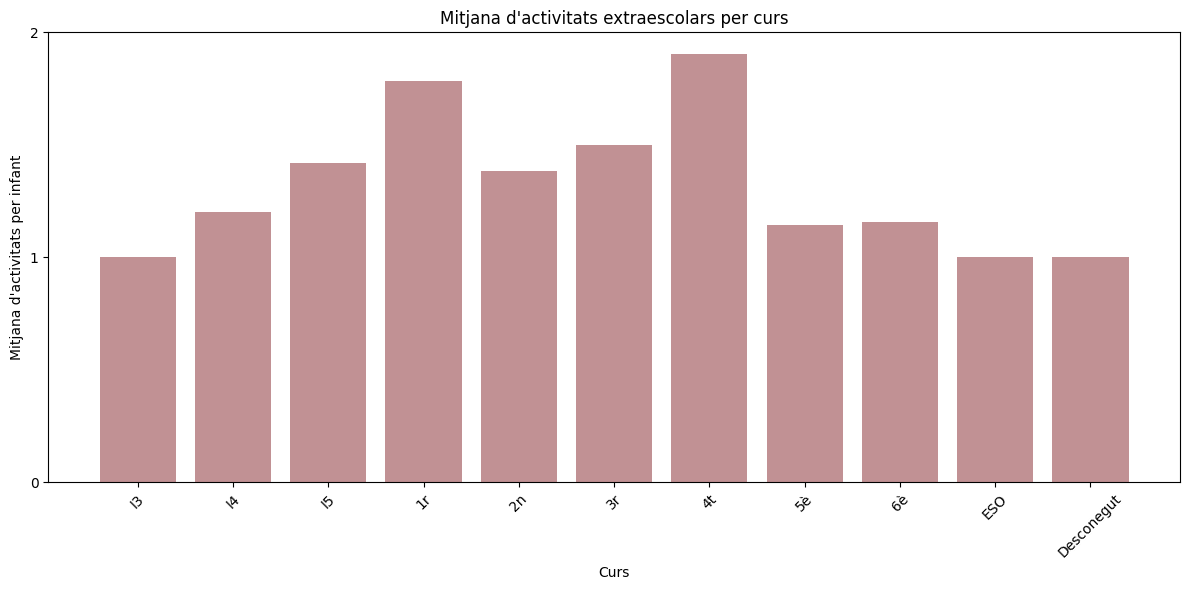

In [475]:
# Calculem el nombre d'activitats diferent que hi ha a la taula all_activities_df
#activitats_diferents = all_activities_df['activitat'].nunique()
#print(f"Nombre d'activitats diferents: {activitats_diferents}")

# Calculem el nombre d'infants diferents que hi ha a la taula all_activities_df
#infants_diferents = all_activities_df['id_infant'].nunique()
#print(f"Nombre d'infants que fan extraescolars i tenen id_infant: {infants_diferents}")




# Contem el número d'activitats per infant 
activities_per_infant = all_activities_df.groupby(['id_infant', 'curs']).size().reset_index(name='num_activitats')

# Estandaritzem el nom dels cursis 
activities_per_infant['curs'] = activities_per_infant['curs'].map(cursos_estandar).fillna(activities_per_infant['curs'])
activities_per_infant['curs'] = pd.Categorical(activities_per_infant['curs'], categories=ordre_cursos, ordered=True)

# Calculem la mitjana d'activitats per curs (contant només els nens que fa nextraescolars)
mitjana_activitats_per_curs = activities_per_infant.groupby('curs')['num_activitats'].mean().reset_index()

# Eliminem els cursos buits
mitjana_activitats_per_curs = mitjana_activitats_per_curs.dropna(subset=['num_activitats'])


# Grafiquem
plt.figure(figsize=(12, 6))
plt.bar(mitjana_activitats_per_curs['curs'], mitjana_activitats_per_curs['num_activitats'], color='#C19194')
plt.xlabel('Curs')
plt.ylabel('Mitjana d\'activitats per infant')
plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.title('Mitjana d\'activitats extraescolars per curs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Activitats per infant

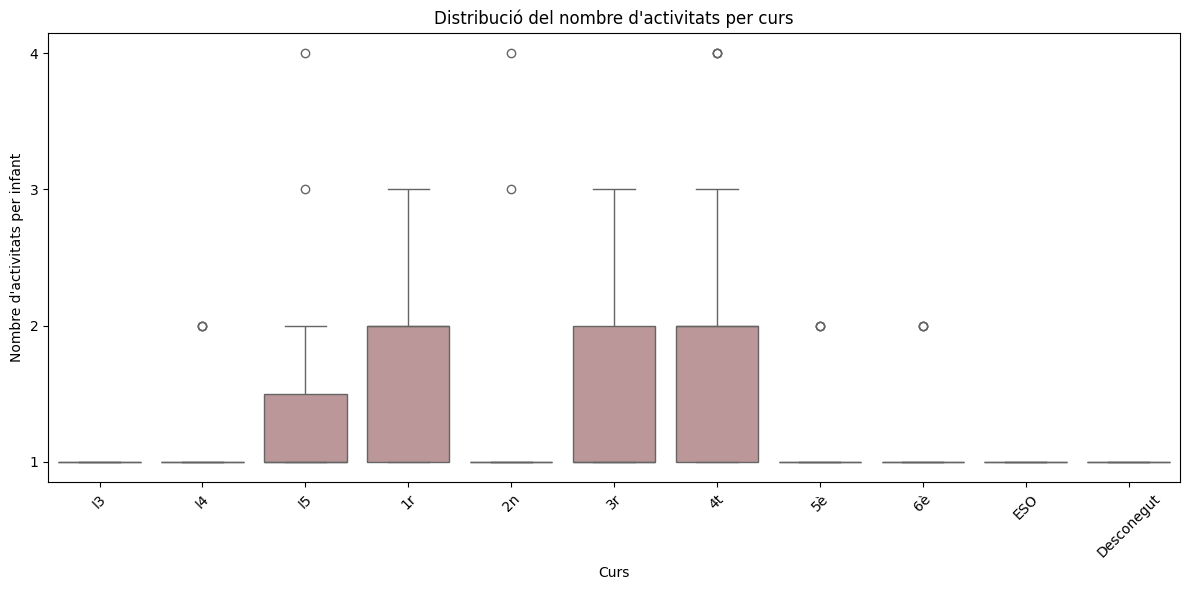

In [480]:
# Contem el número d'activitats per infant 
activities_per_infant = all_activities_df.groupby(['id_infant', 'curs']).size().reset_index(name='num_activitats')

# Normalitzem i ordenem per 'curs' per a un ordre consitent
activities_per_infant['curs'] = activities_per_infant['curs'].map(cursos_estandar).fillna(activities_per_infant['curs'])
activities_per_infant['curs'] = pd.Categorical(activities_per_infant['curs'], categories=ordre_cursos, ordered=True)

# Treiem files buides i categories sense usar 
activities_per_infant = activities_per_infant.dropna(subset=['num_activitats', 'curs'])
activities_per_infant['curs'] = activities_per_infant['curs'].cat.remove_unused_categories()



# Grafiquem
plt.figure(figsize=(12, 6))
sns.boxplot(x='curs', y='num_activitats', data=activities_per_infant, color='#C19194')
plt.xlabel('Curs')
plt.ylabel('Nombre d\'activitats per infant')
plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.title('Distribució del nombre d\'activitats per curs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
